In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pylab as pl
from pathlib import Path

In [2]:
file_path = Path.home() / "Desktop" / "FuelConsumption.csv"
df = pd.read_csv(file_path)

In [3]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.head(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244
5,3.5,6,10.0,230
6,3.5,6,10.1,232
7,3.7,6,11.1,255
8,3.7,6,11.6,267


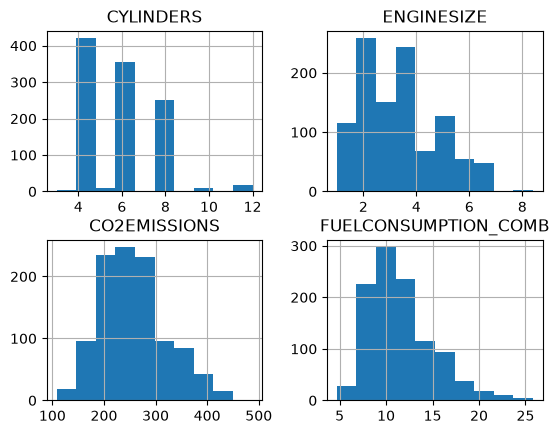

In [4]:
viz = cdf[['CYLINDERS','ENGINESIZE','CO2EMISSIONS','FUELCONSUMPTION_COMB']]
viz.hist()
plt.show()

In [11]:
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]
print(msk)
print(train)
print(test)

[False  True  True ...  True False  True]
      ENGINESIZE  CYLINDERS  FUELCONSUMPTION_COMB  CO2EMISSIONS
1            2.4          4                   9.6           221
2            1.5          4                   5.9           136
3            3.5          6                  11.1           255
4            3.5          6                  10.6           244
5            3.5          6                  10.0           230
...          ...        ...                   ...           ...
1061         3.2          6                  11.2           258
1062         3.0          6                  11.8           271
1063         3.2          6                  11.5           264
1064         3.0          6                  11.8           271
1066         3.2          6                  12.8           294

[881 rows x 4 columns]
      ENGINESIZE  CYLINDERS  FUELCONSUMPTION_COMB  CO2EMISSIONS
0            2.0          4                   8.5           196
12           5.9         12           

In [12]:
from sklearn import linear_model
regr = linear_model.LinearRegression()
train_x = np.asanyarray(train[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])
regr.fit (train_x, train_y)
# The coefficients
print ('Coefficients: ', regr.coef_)
print ('Intercept: ',regr.intercept_)

Coefficients:  [[10.99619981  7.78011535  9.37058424]]
Intercept:  [65.67908977]


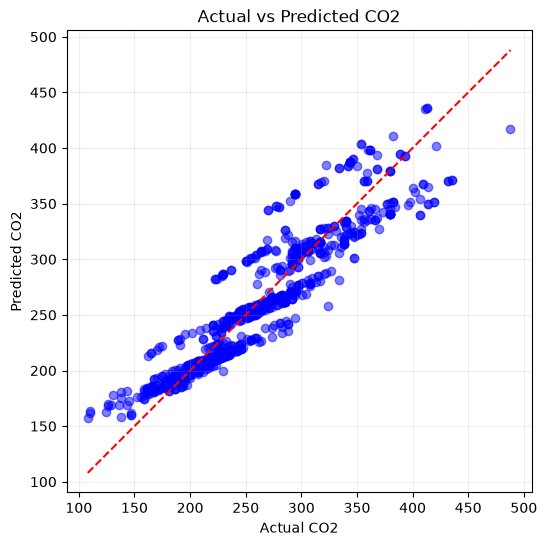

In [ ]:
# مقادیر واقعی و پیش‌بینی‌شده
actual = train_y.ravel()
predicted = regr.predict(train_x).ravel()

plt.figure(figsize=(6, 6))ذ
plt.scatter(actual, predicted, color="blue", alpha=0.5)

# خط پیش‌بینی کاملاً درست
low = min(actual.min(), predicted.min())
high = max(actual.max(), predicted.max())
plt.plot([low, high], [low, high], "r--")

plt.xlabel("Actual CO2")
plt.ylabel("Predicted CO2")
plt.title("Actual vs Predicted CO2")
plt.grid(alpha=0.2)
plt.axis("equal")
plt.show()

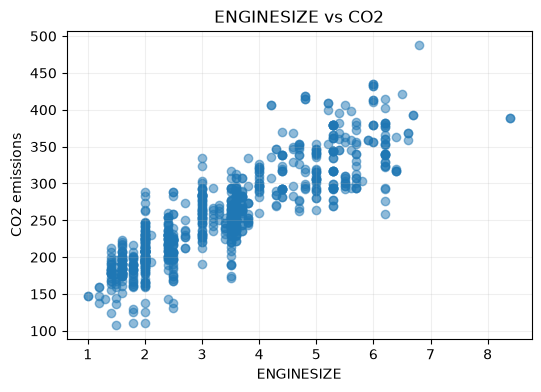

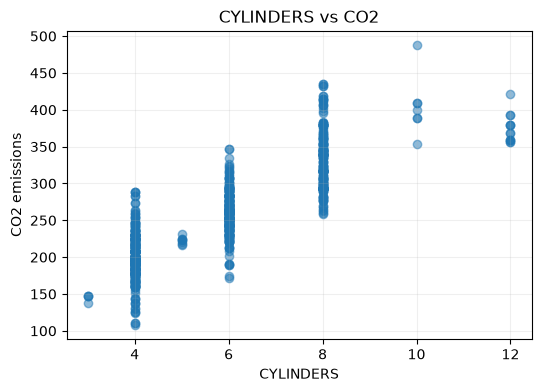

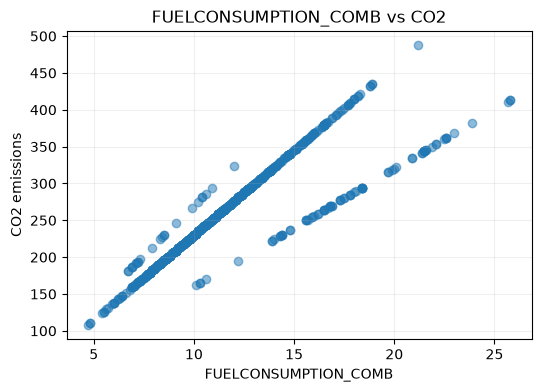

In [15]:
# سه نمودار اول: رابطه هر ورودی با CO2
features = ["ENGINESIZE", "CYLINDERS", "FUELCONSUMPTION_COMB"]

for feature in features:
    plt.figure(figsize=(6, 4))
    plt.scatter(train[feature], train["CO2EMISSIONS"], alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel("CO2 emissions")
    plt.title(f"{feature} vs CO2")
    plt.grid(alpha=0.2)
    plt.show()

plt.show()

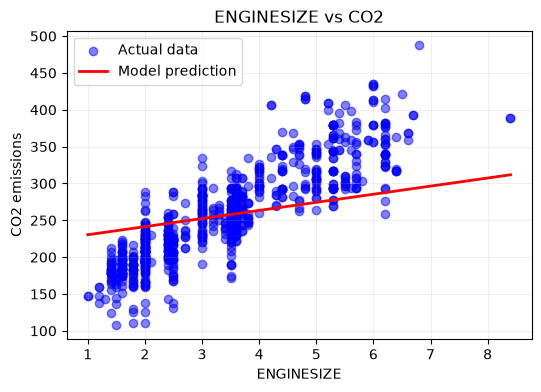

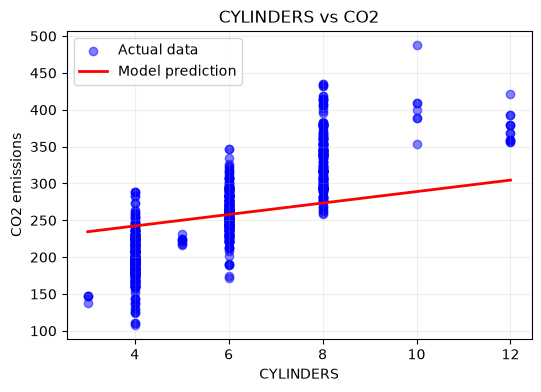

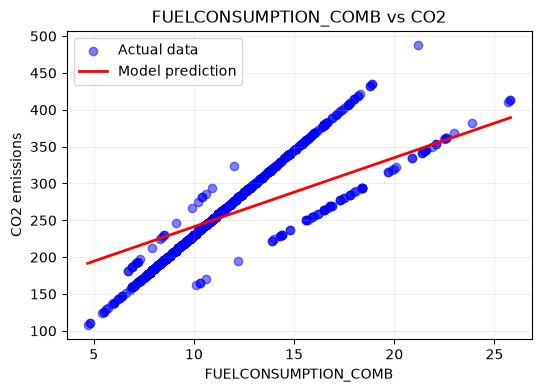

In [ ]:
features = ["ENGINESIZE", "CYLINDERS", "FUELCONSUMPTION_COMB"]

for i, feature in enumerate(features):

    # ساخت ۱۰۰ نقطه برای محور افقی
    x_line = np.linspace(
        train[feature].min(),
        train[feature].max(),
        100
    )

    # ثابت گرفتن ورودی‌ها روی میانگین
    inputs = np.tile(train_x.mean(axis=0), (100, 1))

    # تغییر فقط ویژگی مربوط به این نمودار
    inputs[:, i] = x_line

    # پیش‌بینی با مدل آموزش‌دیده
    y_line = regr.predict(inputs).ravel()

    plt.figure(figsize=(6, 4))

    plt.scatter(ذ
        train[feature], train["CO2EMISSIONS"],
        color="blue", alpha=0.5, label="Actual data"
    )

    plt.plot(
        x_line, y_line,
        color="red", linewidth=2, label="Model prediction"
    )

    plt.xlabel(feature)
    plt.ylabel("CO2 emissions")
    plt.title(f"{feature} vs CO2")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

In [22]:
y_hat = regr.predict(test[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']])
x = np.asanyarray(test[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']])
y = np.asanyarray(test[['CO2EMISSIONS']])
print('residual sum of squares: %.2f' % np.mean((y_hat - y)**2))
print('variance score %.2f' % regr.score(x, y))

residual sum of squares: 497.39
variance score 0.87


c:\Users\farzam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
